<a href="https://colab.research.google.com/github/JLZN80/PYTHON_ROOT/blob/main/mini_demo_var_acciones_ia.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Mini Demo: Python calcula el VaR, la IA ayuda a entender el riesgo

Demo conceptual de **stress testing aumentado por IA** para un portafolio simple de acciones.

**Tesis:** Python calcula el riesgo cuantitativo; la IA ayuda a interpretar, conectar escenarios y preparar mejores preguntas para el comité.

> Uso educativo. No es recomendación de inversión ni modelo regulatorio oficial.


## 1. Importación de librerías
En Colab, descomenta la instalación de `yfinance` si hace falta.

In [1]:
!pip install yfinance --quiet

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm
import yfinance as yf
import json

pd.options.display.float_format = '{:,.4f}'.format


## 2. Definición del portafolio

In [6]:
tickers = ['SPY', 'NVDA', 'MSFT', 'AAPL']
weights = np.array([0.40, 0.25, 0.20, 0.15])
portfolio_value = 1_000_000  # USD

start_date = '2022-01-01'
end_date = None

confidence_levels = [0.95, 0.99]
horizons = [1, 10]

if len(tickers) != len(weights):
    raise ValueError('El número de tickers debe coincidir con el número de pesos.')
if not np.isclose(weights.sum(), 1.0):
    raise ValueError('Los pesos deben sumar 1.0.')

portfolio = pd.DataFrame({
    'Ticker': tickers,
    'Peso': weights,
    'Monto_USD': weights * portfolio_value
})
portfolio


,Ticker,Peso,Monto_USD
0,SPY,0.4000,"400,000.0000"
1,NVDA,0.2500,"250,000.0000"
2,MSFT,0.2000,"200,000.0000"
3,AAPL,0.1500,"150,000.0000"


## 3. Descarga de precios desde Yahoo Finance

In [11]:
raw_data = yf.download(tickers, start=start_date, end=end_date, auto_adjust=True, progress=False)

if isinstance(raw_data.columns, pd.MultiIndex):
    prices = raw_data['Close'].copy()
else:
    prices = raw_data.copy()

prices = prices.dropna()
print(f'Observaciones descargadas: {len(prices)}')
prices.tail()


Observaciones descargadas: 1107


Ticker,AAPL,MSFT,NVDA,SPY
Date,,,,
2026-05-27,310.8500,412.6700,212.6000,750.4600
2026-05-28,312.5100,426.9900,214.2500,754.6000
2026-05-29,312.0600,450.2400,211.1400,756.4800
2026-06-01,306.3100,460.5200,224.3600,758.5400
2026-06-02,315.2000,441.3100,222.8200,759.5700


## 4. Retornos y métricas básicas

In [12]:
returns = prices.pct_change().dropna()
portfolio_returns = returns @ weights

summary_assets = pd.DataFrame({
    'Retorno diario medio': returns.mean(),
    'Volatilidad diaria': returns.std(),
    'Volatilidad anualizada': returns.std() * np.sqrt(252)
})

mean_p = portfolio_returns.mean()
vol_p = portfolio_returns.std()

portfolio_summary = pd.DataFrame({
    'Métrica': ['Retorno diario medio', 'Volatilidad diaria', 'Volatilidad anualizada'],
    'Portafolio': [mean_p, vol_p, vol_p * np.sqrt(252)]
})

display(summary_assets)
display(portfolio_summary)


,Retorno diario medio,Volatilidad diaria,Volatilidad anualizada
Ticker,,,
AAPL,0.0007,0.0177,0.2813
MSFT,0.0004,0.0173,0.2743
NVDA,0.0024,0.0331,0.5254
SPY,0.0005,0.0111,0.1762


,Métrica,Portafolio
0,Retorno diario medio,0.0009
1,Volatilidad diaria,0.0166
2,Volatilidad anualizada,0.2636


## 5. Correlación de activos

Ticker,AAPL,MSFT,NVDA,SPY
Ticker,,,,
AAPL,1.0000,0.5685,0.4995,0.7566
MSFT,0.5685,1.0000,0.6033,0.7222
NVDA,0.4995,0.6033,1.0000,0.7130
SPY,0.7566,0.7222,0.7130,1.0000


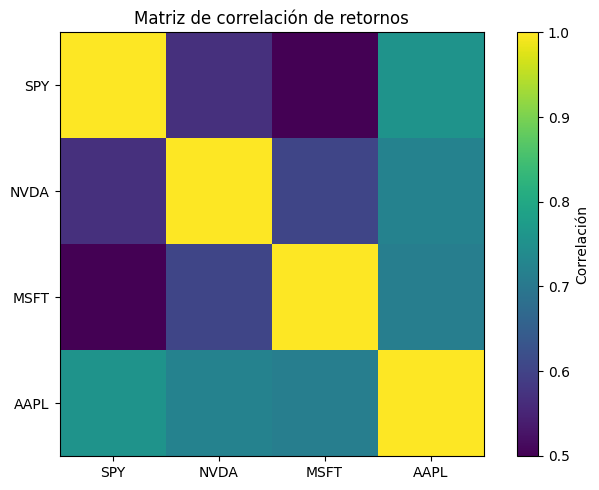

In [13]:
corr = returns.corr()
display(corr)

plt.figure(figsize=(7, 5))
plt.imshow(corr, interpolation='nearest')
plt.xticks(range(len(tickers)), tickers)
plt.yticks(range(len(tickers)), tickers)
plt.colorbar(label='Correlación')
plt.title('Matriz de correlación de retornos')
plt.tight_layout()
plt.show()


## 6. VaR histórico y Expected Shortfall

El VaR histórico usa la distribución observada de retornos pasados.  
El Expected Shortfall mide la pérdida promedio más allá del umbral de VaR.


In [17]:
def historical_var(returns_series, confidence_level, portfolio_value, horizon=1):
    alpha = 1 - confidence_level
    var_return = -np.quantile(returns_series, alpha)
    return var_return * np.sqrt(horizon) * portfolio_value

def historical_es(returns_series, confidence_level, portfolio_value, horizon=1):
    alpha = 1 - confidence_level
    threshold = np.quantile(returns_series, alpha)
    tail_losses = returns_series[returns_series <= threshold]
    es_return = -tail_losses.mean()
    return es_return * np.sqrt(horizon) * portfolio_value

hist_results = []
for cl in confidence_levels:
    for h in horizons:
        hist_results.append({
            'Método': 'Histórico',
            'Confianza': f'{int(cl*100)}%',
            'Horizonte_días': h,
            'VaR_USD': historical_var(portfolio_returns, cl, portfolio_value, h),
            'Expected_Shortfall_USD': historical_es(portfolio_returns, cl, portfolio_value, h)
        })

hist_df = pd.DataFrame(hist_results)
hist_df


,Método,Confianza,Horizonte_días,VaR_USD,Expected_Shortfall_USD
0,Histórico,95%,1,"26,920.1666","36,672.3050"
1,Histórico,95%,10,"85,129.0416","115,968.0109"
2,Histórico,99%,1,"42,820.7584","51,361.0134"
3,Histórico,99%,10,"135,411.1275","162,417.7853"


## 7. VaR paramétrico normal

Asume distribución normal de retornos. Es útil como aproximación inicial, pero puede subestimar colas gruesas o eventos extremos.


In [18]:
def parametric_var_normal(mean_return, vol_return, confidence_level, portfolio_value, horizon=1):
    alpha = 1 - confidence_level
    z = norm.ppf(alpha)
    var_return = -(mean_return * horizon + z * vol_return * np.sqrt(horizon))
    return var_return * portfolio_value

def parametric_es_normal(mean_return, vol_return, confidence_level, portfolio_value, horizon=1):
    alpha = 1 - confidence_level
    z = norm.ppf(alpha)
    es_return = -(mean_return * horizon - vol_return * np.sqrt(horizon) * norm.pdf(z) / alpha)
    return es_return * portfolio_value

param_results = []
for cl in confidence_levels:
    for h in horizons:
        param_results.append({
            'Método': 'Paramétrico Normal',
            'Confianza': f'{int(cl*100)}%',
            'Horizonte_días': h,
            'VaR_USD': parametric_var_normal(mean_p, vol_p, cl, portfolio_value, h),
            'Expected_Shortfall_USD': parametric_es_normal(mean_p, vol_p, cl, portfolio_value, h)
        })

param_df = pd.DataFrame(param_results)
param_df


,Método,Confianza,Horizonte_días,VaR_USD,Expected_Shortfall_USD
0,Paramétrico Normal,95%,1,"26,381.8838","33,319.7915"
1,Paramétrico Normal,95%,10,"77,078.8676","99,018.4580"
2,Paramétrico Normal,99%,1,"37,697.0455","43,323.3989"
3,Paramétrico Normal,99%,10,"112,860.5504","130,652.6421"


## 8. Consolidado de resultados

In [19]:
risk_results = pd.concat([hist_df, param_df], ignore_index=True)
risk_results['VaR_%_Portafolio'] = risk_results['VaR_USD'] / portfolio_value
risk_results['ES_%_Portafolio'] = risk_results['Expected_Shortfall_USD'] / portfolio_value
risk_results


,Método,Confianza,Horizonte_días,VaR_USD,Expected_Shortfall_USD,VaR_%_Portafolio,ES_%_Portafolio
0,Histórico,95%,1,"26,920.1666","36,672.3050",0.0269,0.0367
1,Histórico,95%,10,"85,129.0416","115,968.0109",0.0851,0.1160
2,Histórico,99%,1,"42,820.7584","51,361.0134",0.0428,0.0514
3,Histórico,99%,10,"135,411.1275","162,417.7853",0.1354,0.1624
4,Paramétrico Normal,95%,1,"26,381.8838","33,319.7915",0.0264,0.0333
5,Paramétrico Normal,95%,10,"77,078.8676","99,018.4580",0.0771,0.0990
6,Paramétrico Normal,99%,1,"37,697.0455","43,323.3989",0.0377,0.0433
7,Paramétrico Normal,99%,10,"112,860.5504","130,652.6421",0.1129,0.1307


## 9. Gráfico de distribución de retornos

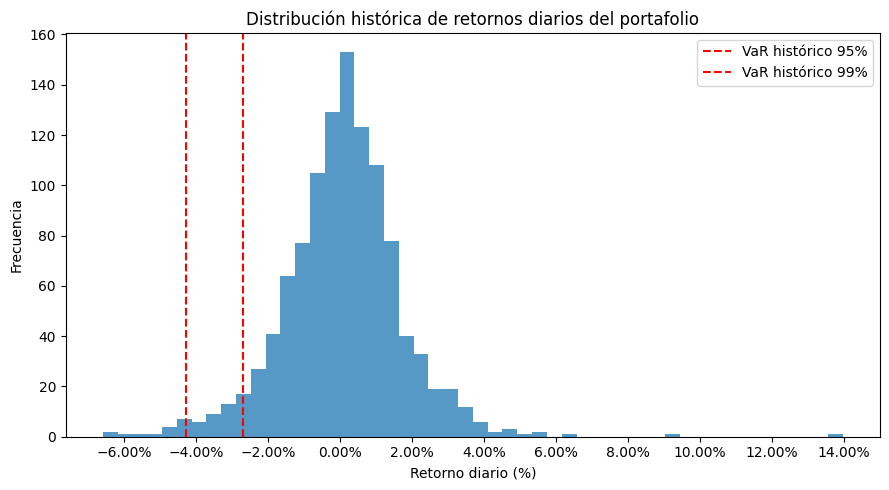

In [28]:
import matplotlib.ticker as mtick

plt.figure(figsize=(9, 5))
plt.hist(portfolio_returns, bins=50, alpha=0.75)

for cl in confidence_levels:
    var_threshold = np.quantile(portfolio_returns, 1 - cl)
    plt.axvline(var_threshold, color='red', linestyle='--', label=f'VaR histórico {int(cl*100)}%')

# Formatear el eje X como porcentaje
ax = plt.gca()
ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0, decimals=2))

# Establecer el delta (intervalo) de las marcas en 2% (0.02)
ax.xaxis.set_major_locator(mtick.MultipleLocator(0.02))

plt.title('Distribución histórica de retornos diarios del portafolio')
plt.xlabel('Retorno diario (%)')
plt.ylabel('Frecuencia')
plt.legend()
plt.tight_layout()
plt.show()

## 10. Stress testing simple

In [33]:
stress_scenarios = {
    'Caída leve (-3%)': -0.03,
    'Caída moderada (-7%)': -0.07,
    'Caída severa (-12%)': -0.12,
    'Caída extrema (-20%)': -0.20,
}

stress_df = pd.DataFrame([
    {
        'Escenario': name,
        'Shock_portafolio': shock,
        'Pérdida_USD': -shock * portfolio_value,
        'Valor_post_stress_USD': portfolio_value * (1 + shock)
    }
    for name, shock in stress_scenarios.items()
])
stress_df


,Escenario,Shock_portafolio,Pérdida_USD,Valor_post_stress_USD
0,Caída leve (-3%),-0.0300,"30,000.0000","970,000.0000"
1,Caída moderada (-7%),-0.0700,"70,000.0000","930,000.0000"
2,Caída severa (-12%),-0.1200,"120,000.0000","880,000.0000"
3,Caída extrema (-20%),-0.2000,"200,000.0000","800,000.0000"


## 11. Resumen para el GPT/copiloto

Esta salida se copia y pega en el GPT para que genere interpretación ejecutiva, escenarios narrativos y preguntas de comité.


In [56]:
from google.colab import files
import json

summary_for_gpt = {
    'objetivo': 'Interpretar resultados de VaR y stress testing para un comité de riesgos.',
    'advertencia': 'Demo educativa. No es recomendación de inversión ni modelo regulatorio oficial.',
    'portafolio': portfolio.to_dict(orient='records'),
    'periodo_precios': {
        'inicio': str(prices.index.min().date()),
        'fin': str(prices.index.max().date()),
        'observaciones': int(len(prices))
    },
    'metricas_portafolio': {
        'retorno_diario_medio': float(mean_p),
        'volatilidad_diaria': float(vol_p),
        'volatilidad_anualizada': float(vol_p * np.sqrt(252))
    },
    'resultados_var_es': risk_results.to_dict(orient='records'),
    'stress_tests': stress_df.to_dict(orient='records'),
    'correlacion': corr.round(4).to_dict(),
    'instruccion_para_gpt': {
        'rol': 'Actúa como copiloto de escenarios de riesgo financiero.',
        'tareas': [
            'Explicar los resultados en lenguaje ejecutivo.',
            'Identificar principales fuentes de riesgo del portafolio.',
            'Sugerir escenarios narrativos que podrían no estar capturados por el VaR.',
            'Proponer señales tempranas a monitorear.',
            'Preparar preguntas para un comité de riesgos.',
            'Indicar limitaciones del VaR y del análisis histórico.',
            'Sugerir qué recalcular o validar en Python.'
        ],
        'restricciones': [
            'No recomendar comprar o vender activos.',
            'No presentar escenarios como predicciones.',
            'No reemplazar juicio experto ni validación independiente.',
            'Separar resultados cuantitativos de interpretación cualitativa.'
        ]
    }
}

# 1. Mostrar el JSON en consola
print(json.dumps(summary_for_gpt, indent=2, ensure_ascii=False))

# 2. Exportar y descargar el archivo automáticamente
file_name = 'Resultados_Motor_VaR.json'
with open(file_name, 'w', encoding='utf-8') as f:
    json.dump(summary_for_gpt, f, indent=2, ensure_ascii=False)

files.download(file_name)
print(f'\nArchivo {file_name} generado y descargado.')

{
  "objetivo": "Interpretar resultados de VaR y stress testing para un comité de riesgos.",
  "advertencia": "Demo educativa. No es recomendación de inversión ni modelo regulatorio oficial.",
  "portafolio": [
    {
      "Ticker": "SPY",
      "Peso": 0.4,
      "Monto_USD": 400000.0
    },
    {
      "Ticker": "NVDA",
      "Peso": 0.25,
      "Monto_USD": 250000.0
    },
    {
      "Ticker": "MSFT",
      "Peso": 0.2,
      "Monto_USD": 200000.0
    },
    {
      "Ticker": "AAPL",
      "Peso": 0.15,
      "Monto_USD": 150000.0
    }
  ],
  "periodo_precios": {
    "inicio": "2022-01-03",
    "fin": "2026-06-02",
    "observaciones": 1107
  },
  "metricas_portafolio": {
    "retorno_diario_medio": 0.0009283755578983936,
    "volatilidad_diaria": 0.016603458772188235,
    "volatilidad_anualizada": 0.2635717368883434
  },
  "resultados_var_es": [
    {
      "Método": "Histórico",
      "Confianza": "95%",
      "Horizonte_días": 1,
      "VaR_USD": 26920.166639750627,
      "Expe

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


Archivo Resultados_Motor_VaR.json generado y descargado.


## 12. Prompt sugerido para el GPT/copiloto

Copia el JSON anterior y pégalo debajo de este prompt:

```text
Actúa como copiloto de escenarios de riesgo financiero.

Tu función no es reemplazar al analista ni al modelo cuantitativo. Tu función es interpretar resultados de VaR/stress testing, identificar riesgos no evidentes, sugerir escenarios narrativos, proponer señales tempranas a monitorear y preparar preguntas para un comité de riesgos.

Usa el JSON de resultados que te comparto como fuente principal. No inventes cifras. No recomiendes comprar o vender activos. Separa claramente:

1. Lectura cuantitativa.
2. Interpretación ejecutiva.
3. Escenarios narrativos no capturados por el VaR.
4. Señales tempranas a monitorear.
5. Preguntas para el comité.
6. Limitaciones del análisis.
7. Qué debería recalcularse o validarse en Python.

Mantén tono ejecutivo, técnico y pedagógico.
```


### Exportación consolidada
La descarga automática de `Resultados_Motor_VaR.json` ahora ocurre dentro de la celda de resumen anterior.